<a href="https://colab.research.google.com/github/OscarLacomba/Water_Classification_GeoAI/blob/main/LandCover_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Land Cover Classification — MODIS Lake Powell

> **Remote Sensing · Machine Learning · Explainable AI**
>
> Dataset: [NASA CISTO — MODIS Lake Powell](https://huggingface.co/datasets/nasa-cisto-data-science-group/modis-lake-powell-toy-dataset)

**Steps:** Import Libraries · Load Data · EDA · Feature Engineering · Split · Train · Evaluate · XAI


# Introduction to Geospatial AI (GeoAI)

# Object:

Our goal is to create several models capable of classifying water and land cover features from remote sensing data. We will work through the entire data science lifecycle. At the end of the class, you will submit the final notebook you have from this exercise.

# Land Cover Classification

# Task

1.Import the necessary libraries

2.Load the Dataset

3.Perform EDA (at least 4 visualizations)

4.Perform Feature Engineering

5.Split the Dataset (train and test sets)

6.Initialize and train any type of classification model

7.Make predictions and evaluate the model

8.Perform Explainable AI Analysis Looking at Feature Importance


# Utilization

1.Google Colab

2.Pytho Libraries:
-pandas

-numpy

-matplotlib

-seaborn

-plotly

-scikit-learn

-RandomForestClassifier

-Claude For Mac 1.7





Autor: Oscar Martinez Gracia - oskytm@hotmail.com

Created:2026-05-15

Modified:2026-05-16

Finish:2026-05-17

Curso:Data Science



---
## 1. Install & Import Libraries

In [ ]:
!pip install -q datasets huggingface_hub shap lightgbm plotly xgboost


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
import xgboost as xgb
import lightgbm as lgb
import shap

PALETTE = ['#64ffda','#f07178','#c3e88d','#82aaff','#ffcb6b','#ff5572']
plt.rcParams.update({
    'figure.facecolor':'#0f1117','axes.facecolor':'#1a1d2e',
    'axes.labelcolor':'#c8d0e7','xtick.color':'#8892b0',
    'ytick.color':'#8892b0','text.color':'#e6eaf4',
    'grid.color':'#2a2f4a','figure.dpi':110,
})
sns.set_palette(PALETTE)
print('Libraries ready!')


Libraries ready!


---
## 2. Load the Dataset

In [ ]:
BASE = (
    'https://huggingface.co/datasets/'
    'nasa-cisto-data-science-group/modis-lake-powell-toy-dataset/resolve/main/'
)

df_train = pd.read_csv(BASE + 'train.csv')
df_test  = pd.read_csv(BASE + 'test.csv')

print(f'Train shape : {df_train.shape}')
print(f'Test  shape : {df_test.shape}')
display(df_train.head())


Train shape : (800, 11)
Test  shape : (200, 11)


,water,sur_refl_b01_1,sur_refl_b02_1,sur_refl_b03_1,sur_refl_b04_1,sur_refl_b05_1,sur_refl_b06_1,sur_refl_b07_1,ndvi,ndwi1,ndwi2
0,0,2031,3113,776,1200,3626,3480,2957,2103,-556,257
1,1,410,494,183,319,295,329,307,929,2004,2334
2,0,1609,2615,797,1000,2143,1708,1107,2381,2098,4051
3,0,2593,3315,1250,1944,3923,4194,3909,1222,-1170,-822
4,0,2485,3365,905,1527,4520,4646,4137,1504,-1599,-1029


In [ ]:
# ── Inspect columns to identify the correct target ────────────────────────────
print('=== Column summary ===')
for col in df_train.columns:
    n   = df_train[col].nunique()
    ex  = df_train[col].iloc[0]
    dt  = df_train[col].dtype
    print(f'  {col:<35} dtype={str(dt):<10} unique={n:<6} example={ex}')


=== Column summary ===
  water                               dtype=int64      unique=2      example=0
  sur_refl_b01_1                      dtype=int64      unique=674    example=2031
  sur_refl_b02_1                      dtype=int64      unique=666    example=3113
  sur_refl_b03_1                      dtype=int64      unique=600    example=776
  sur_refl_b04_1                      dtype=int64      unique=642    example=1200
  sur_refl_b05_1                      dtype=int64      unique=729    example=3626
  sur_refl_b06_1                      dtype=int64      unique=717    example=3480
  sur_refl_b07_1                      dtype=int64      unique=715    example=2957
  ndvi                                dtype=int64      unique=748    example=2103
  ndwi1                               dtype=int64      unique=756    example=-556
  ndwi2                               dtype=int64      unique=756    example=257


In [ ]:
# ── Identify target column robustly ──────────────────────────────────────────
# Priority 1: known label column names
KNOWN = ('label','class','target','landcover','land_cover','lc','category',
         'type','land_use','landuse','cover')
candidates = [c for c in df_train.columns if c.lower() in KNOWN]

# Priority 2: non-numeric columns (likely categorical labels)
if not candidates:
    candidates = df_train.select_dtypes(exclude=np.number).columns.tolist()

# Priority 3: numeric column with few unique values (< 50) — true class label
if not candidates:
    candidates = [c for c in df_train.columns
                  if df_train[c].nunique() < 50]

TARGET = candidates[0] if candidates else df_train.columns[-1]
print(f'Target column  : "{TARGET}"')
print(f'Unique classes : {df_train[TARGET].nunique()}')
print(df_train[TARGET].value_counts().head(20))

# Sanity check — warn if still looks like an ID column
if df_train[TARGET].nunique() > 50:
    print('\n⚠️  WARNING: target has many unique values — may be an ID column!')
    print('   Please set TARGET manually below:')
    print('   TARGET = "<your_label_column>"')


Target column  : "water"
Unique classes : 2
water
1    405
0    395
Name: count, dtype: int64


In [ ]:
# ── SET TARGET MANUALLY IF NEEDED ────────────────────────────────────────────
# Uncomment and edit the line below if the auto-detection above is wrong:
# TARGET = 'label'

feature_cols = [c for c in df_train.columns if c != TARGET]
num_features = (df_train[feature_cols]
                .select_dtypes(include=np.number)
                .columns.tolist())
print(f'Feature columns : {len(num_features)}')
print(f'Target          : {TARGET}')
print(f'Classes         : {sorted(df_train[TARGET].unique())}')


Feature columns : 10
Target          : water
Classes         : [np.int64(0), np.int64(1)]


---
## 3. Exploratory Data Analysis (EDA)

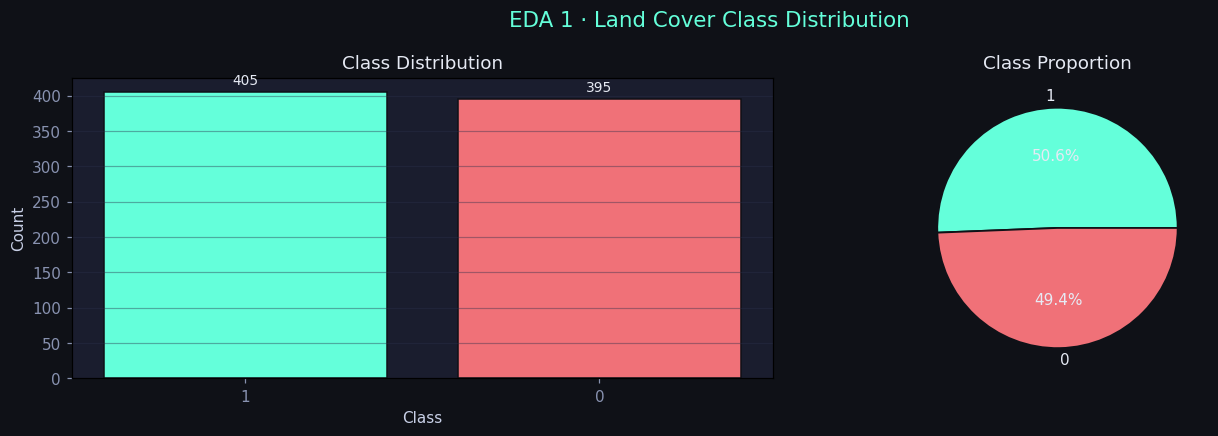

In [ ]:
# ── EDA 1: Class distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0f1117')

cc = df_train[TARGET].value_counts()
bars = axes[0].bar(cc.index.astype(str), cc.values,
                   color=PALETTE[:len(cc)], edgecolor='#0f1117')
axes[0].set_title('Class Distribution', fontsize=12)
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].bar_label(bars, fmt='%d', padding=3, fontsize=9)
axes[0].grid(axis='y', alpha=0.4)

axes[1].pie(cc.values, labels=cc.index.astype(str), autopct='%1.1f%%',
            colors=PALETTE[:len(cc)],
            wedgeprops=dict(edgecolor='#0f1117', linewidth=1.2))
axes[1].set_title('Class Proportion', fontsize=12)
plt.suptitle('EDA 1 · Land Cover Class Distribution', color='#64ffda', fontsize=14)
plt.tight_layout(); plt.show()


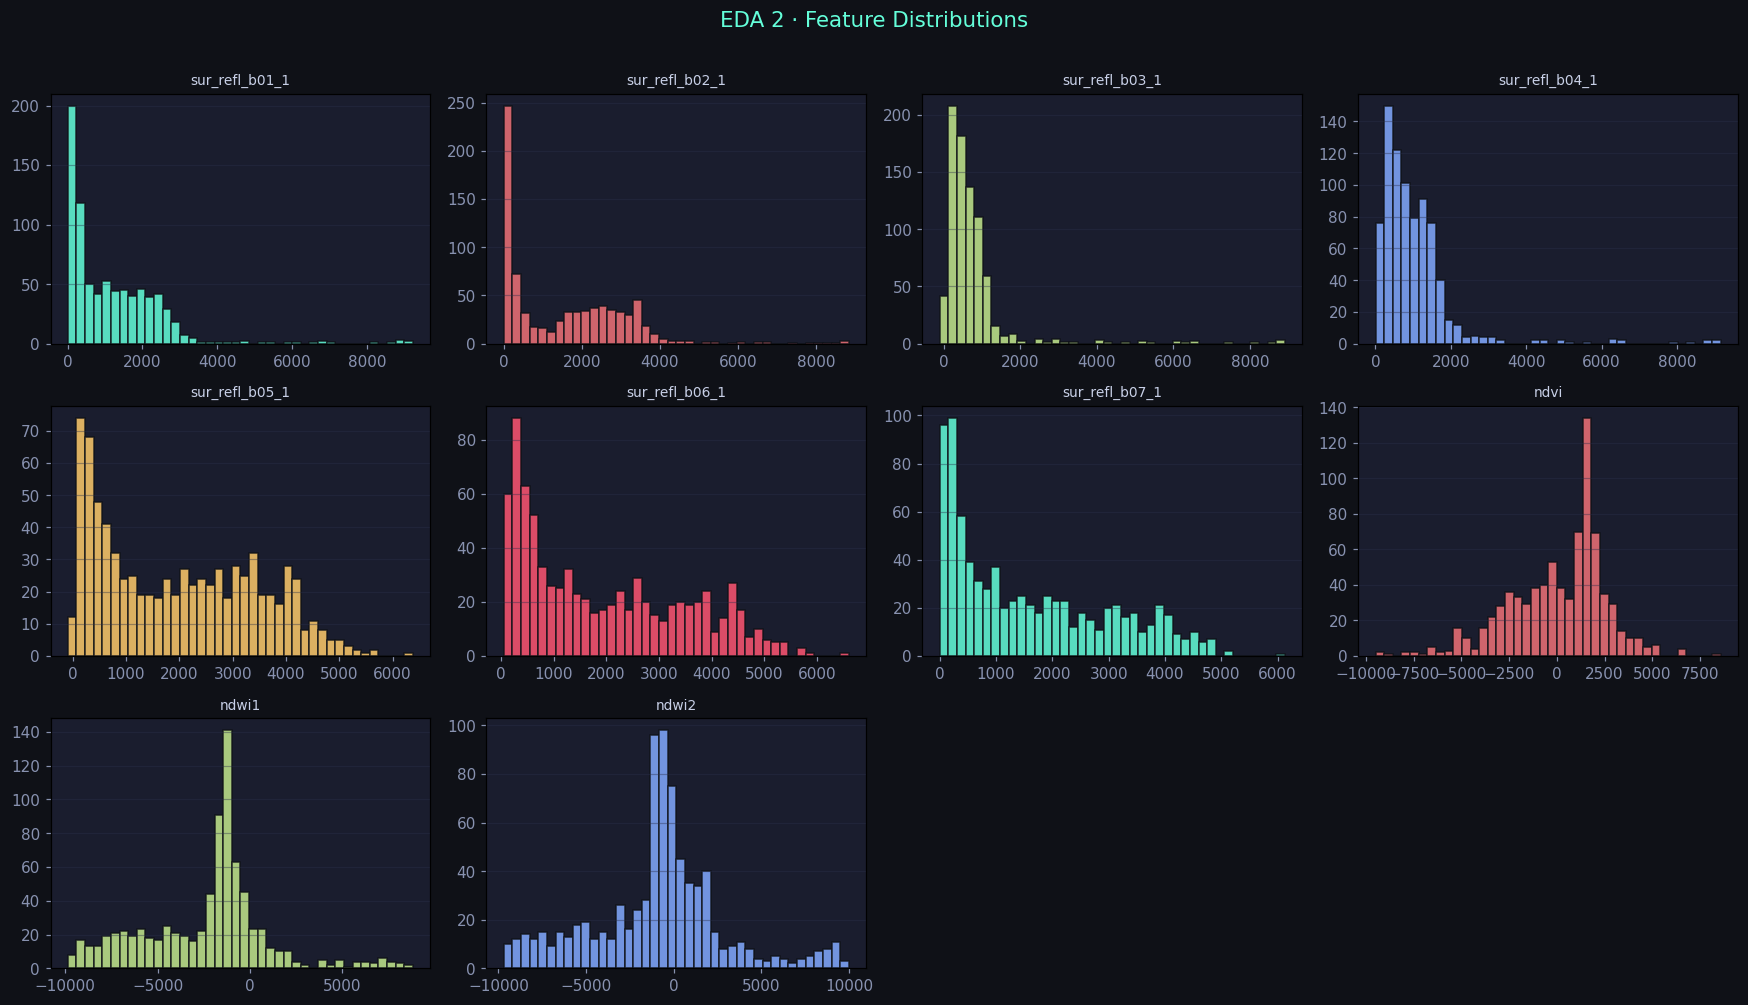

In [ ]:
# ── EDA 2: Feature histograms ─────────────────────────────────────────────────
n = min(len(num_features), 12)
ncols = 4; nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*3))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

for i, col in enumerate(num_features[:n]):
    axes[i].hist(df_train[col].dropna(), bins=40,
                 color=PALETTE[i % len(PALETTE)], edgecolor='#0f1117', alpha=0.85)
    axes[i].set_title(col, fontsize=9, color='#c8d0e7')
    axes[i].grid(axis='y', alpha=0.4)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('EDA 2 · Feature Distributions', color='#64ffda', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


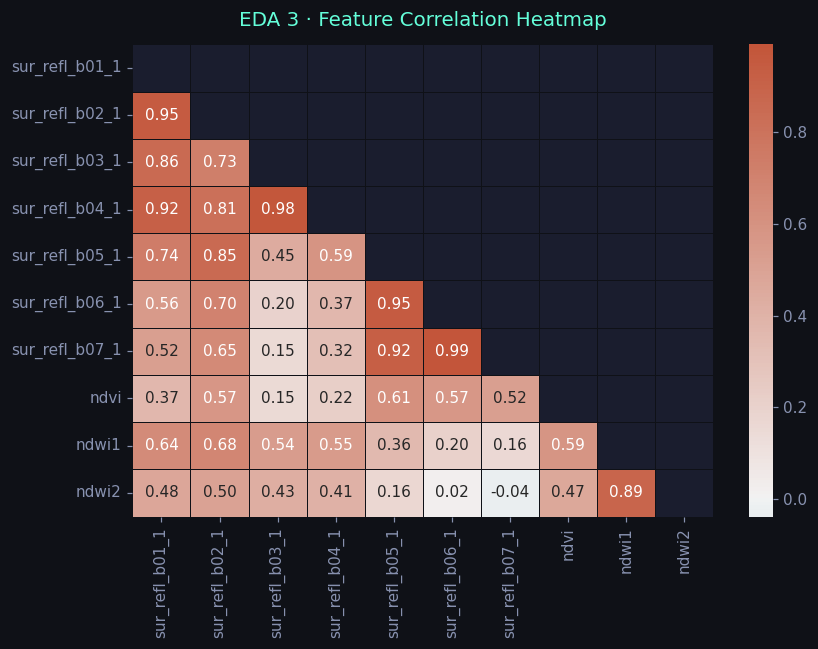

In [ ]:
# ── EDA 3: Correlation heatmap ────────────────────────────────────────────────
corr = df_train[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(max(8, len(num_features)*0.65),
                                max(6, len(num_features)*0.55)))
fig.patch.set_facecolor('#0f1117')
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
            annot=(len(num_features) <= 15), fmt='.2f',
            linewidths=0.4, linecolor='#0f1117', ax=ax)
ax.set_title('EDA 3 · Feature Correlation Heatmap', color='#64ffda', fontsize=13, pad=12)
plt.tight_layout(); plt.show()


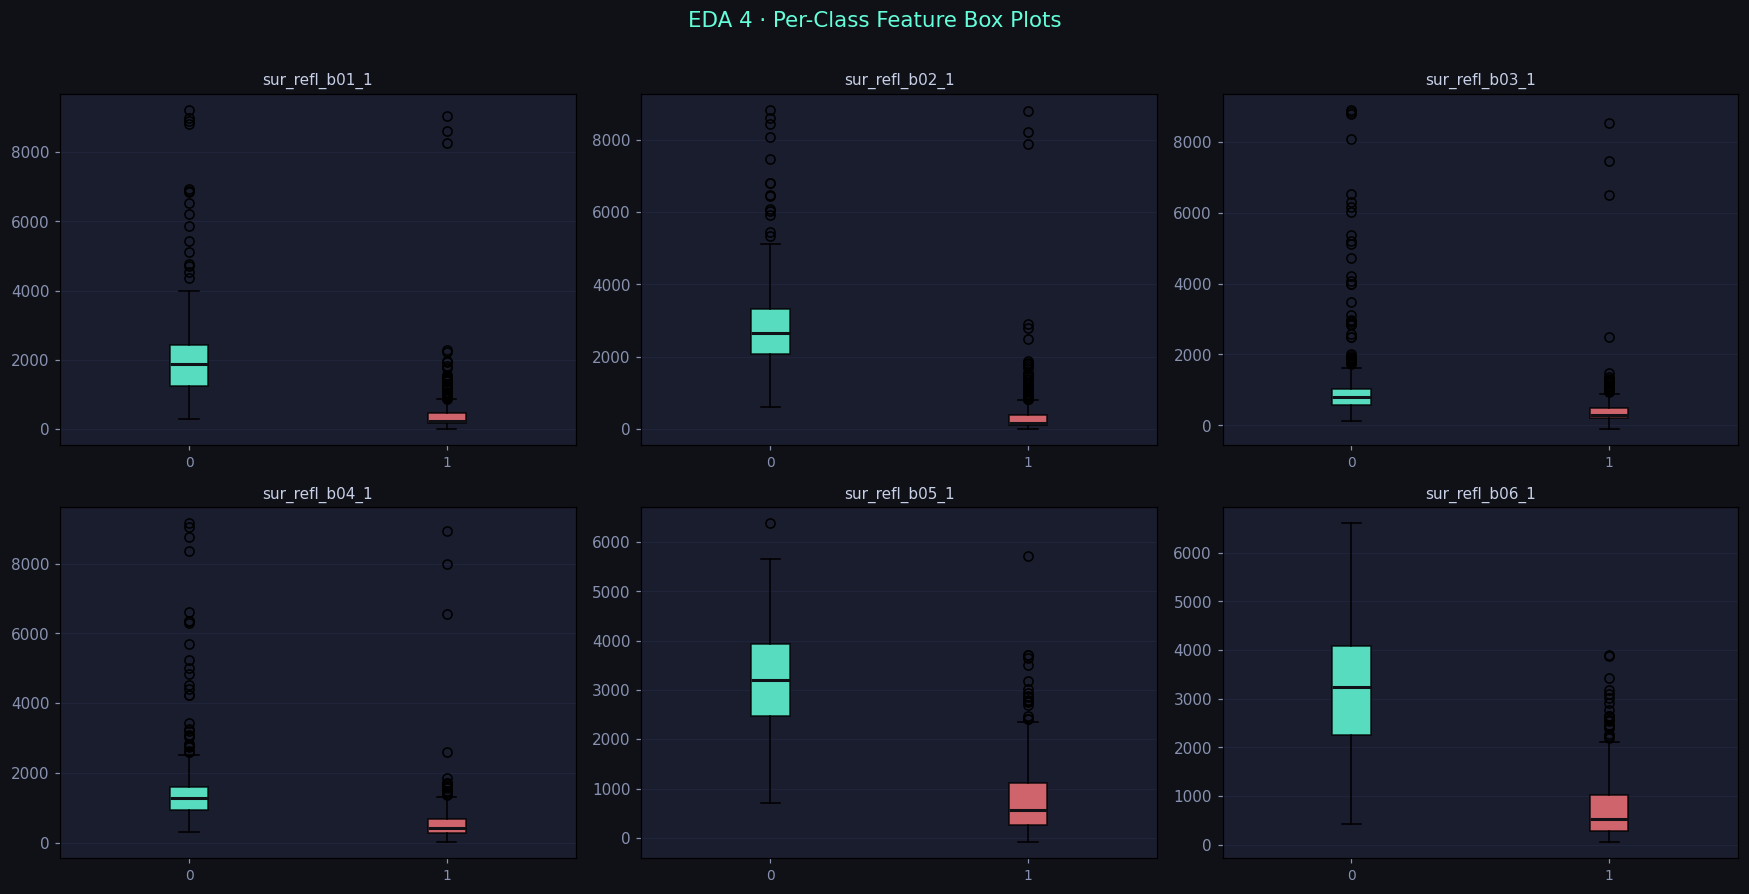

In [ ]:
# ── EDA 4: Per-class box plots ────────────────────────────────────────────────
top_feats    = num_features[:min(6, len(num_features))]
class_labels = df_train[TARGET].unique()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    groups = [df_train.loc[df_train[TARGET]==cl, feat].dropna().values
              for cl in class_labels]
    bp = axes[i].boxplot(groups, patch_artist=True,
                         medianprops=dict(color='#0f1117', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.85)
    axes[i].set_xticklabels([str(c) for c in class_labels], fontsize=9)
    axes[i].set_title(feat, fontsize=10, color='#c8d0e7')
    axes[i].grid(axis='y', alpha=0.4)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('EDA 4 · Per-Class Feature Box Plots', color='#64ffda', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


In [ ]:
# ── EDA 5 (Bonus): Interactive Plotly scatter ─────────────────────────────────
if len(num_features) >= 2:
    f1_col, f2_col = num_features[0], num_features[1]
    sample = df_train.sample(min(3000, len(df_train)), random_state=42)
    fig = px.scatter(sample, x=f1_col, y=f2_col,
                     color=sample[TARGET].astype(str),
                     title=f'EDA 5 · {f1_col} vs {f2_col} by Class',
                     color_discrete_sequence=PALETTE,
                     opacity=0.7, template='plotly_dark')
    fig.update_layout(height=450)
    fig.show()


---
## 4. Feature Engineering

In [ ]:
def engineer_features(df, num_features):
    df = df.copy()
    band_map = {}
    for col in num_features:
        lc = col.lower()
        if any(k in lc for k in ('sur_refl_b01','_red','_b1')): band_map['red']   = col
        if any(k in lc for k in ('sur_refl_b02','_nir','_b2')): band_map['nir']   = col
        if any(k in lc for k in ('sur_refl_b06','swir','_b6')): band_map['swir']  = col
        if any(k in lc for k in ('sur_refl_b04','green','_b4')): band_map['green']= col

    if 'nir' in band_map and 'red' in band_map:
        nir, red = df[band_map['nir']], df[band_map['red']]
        df['NDVI'] = (nir - red) / (nir + red + 1e-8)
        print('  NDVI created')

    if 'nir' in band_map and 'swir' in band_map:
        nir, swir = df[band_map['nir']], df[band_map['swir']]
        df['NDWI'] = (nir - swir) / (nir + swir + 1e-8)
        print('  NDWI created')

    if 'green' in band_map and 'nir' in band_map:
        green, nir = df[band_map['green']], df[band_map['nir']]
        df['MNDWI'] = (green - nir) / (green + nir + 1e-8)
        print('  MNDWI created')

    df['feat_mean']  = df[num_features].mean(axis=1)
    df['feat_std']   = df[num_features].std(axis=1)
    df['feat_range'] = df[num_features].max(axis=1) - df[num_features].min(axis=1)
    print('  Statistical aggregates created')
    return df

print('Engineering train...')
df_train_eng = engineer_features(df_train, num_features)
print('Engineering test...')
df_test_eng  = engineer_features(df_test,  num_features)

num_features_eng = (df_train_eng[[c for c in df_train_eng.columns if c != TARGET]]
                    .select_dtypes(include=np.number).columns.tolist())
print(f'Features: {len(num_features)} -> {len(num_features_eng)}')


Engineering train...
  NDVI created
  NDWI created
  MNDWI created
  Statistical aggregates created
Engineering test...
  NDVI created
  NDWI created
  MNDWI created
  Statistical aggregates created
Features: 10 -> 16


---
## 5. Encode Labels & Train/Test Split

**Fix aplicado:** el `LabelEncoder` se entrena **solo con el conjunto train** para que las clases codificadas sean consecutivas (0, 1, 2 … N-1), requisito de XGBoost.
Las clases del test que no aparezcan en train se marcan como `-1` y se excluyen de la evaluación.

In [ ]:
# ── FIX: LabelEncoder fit ONLY on train ─────────────────────────────────────
le = LabelEncoder()
le.fit(df_train_eng[TARGET])          # ← solo train, no test

y_train_full = le.transform(df_train_eng[TARGET])

# Test labels: transform known classes; mark unknowns as -1
known_classes = set(le.classes_)
y_test_raw = df_test_eng[TARGET].values
y_test = np.array(
    [le.transform([c])[0] if c in known_classes else -1
     for c in y_test_raw]
)

n_unknown = (y_test == -1).sum()
print(f'Classes in train     : {len(le.classes_)}')
print(f'Encoded range        : {y_train_full.min()} – {y_train_full.max()}')
print(f'Test samples unknown : {n_unknown} '
      f'({n_unknown/len(y_test)*100:.1f}%) — excluded from evaluation')

# Feature matrices
X_train_full = df_train_eng[num_features_eng].fillna(
    df_train_eng[num_features_eng].median())
X_test_all   = df_test_eng[num_features_eng].fillna(
    df_test_eng[num_features_eng].median())

# Keep only test rows with known labels for evaluation
mask_known = y_test != -1
X_test = X_test_all[mask_known]
y_test = y_test[mask_known]
print(f'X_train_full : {X_train_full.shape}')
print(f'X_test       : {X_test.shape}')


Classes in train     : 2
Encoded range        : 0 – 1
Test samples unknown : 0 (0.0%) — excluded from evaluation
X_train_full : (800, 16)
X_test       : (200, 16)


In [ ]:
# ── Validation split (stratified) ────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15, random_state=42,
    stratify=y_train_full   # ensures all classes appear in both splits
)

print(f'Train      : {X_train.shape[0]:,}')
print(f'Validation : {X_val.shape[0]:,}')
print(f'Test       : {X_test.shape[0]:,}')
print(f'Features   : {X_train.shape[1]}')
print(f'Classes    : {len(le.classes_)}')


Train      : 680
Validation : 120
Test       : 200
Features   : 16
Classes    : 2


---
## 6. Model Training

In [ ]:
# ── Model definitions (XGBoost fix: no use_label_encoder, no num_class) ──────
n_classes = len(le.classes_)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12,
        random_state=42, n_jobs=-1),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss',        # no use_label_encoder, no num_class
        random_state=42, n_jobs=-1, verbosity=0),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        num_leaves=63, random_state=42, n_jobs=-1, verbose=-1),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average='weighted', zero_division=0)
    results[name] = {'model': model, 'val_acc': acc, 'val_f1': f1}
    print(f'Acc={acc:.4f}  F1={f1:.4f}')

best_name  = max(results, key=lambda k: results[k]['val_f1'])
best_model = results[best_name]['model']
print(f'\nBest model: {best_name}')


Training Random Forest... Acc=0.9833  F1=0.9833
Training XGBoost... Acc=0.9667  F1=0.9667
Training LightGBM... Acc=0.9750  F1=0.9750

Best model: Random Forest


In [ ]:
# ── Cross-validation on full train ───────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_model, X_train_full, y_train_full,
    cv=cv, scoring='f1_weighted', n_jobs=-1
)
print(f'CV F1: {cv_scores.round(4)}  ->  {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

# Retrain on full training data
best_model.fit(X_train_full, y_train_full)
print('Retrained on full training set.')


CV F1: [0.975  0.975  0.9938 0.9938 0.975 ]  ->  0.9825 +/- 0.0092
Retrained on full training set.


---
## 7. Predictions & Evaluation

In [ ]:
y_pred = best_model.predict(X_test)

print(f'Test Accuracy    : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test F1 (weighted): {f1_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print()
print(classification_report(
    y_test, y_pred,
    target_names=[str(c) for c in le.inverse_transform(np.unique(y_test))],
    zero_division=0
))


Test Accuracy    : 0.9900
Test F1 (weighted): 0.9900

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       105
           1       0.98      1.00      0.99        95

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



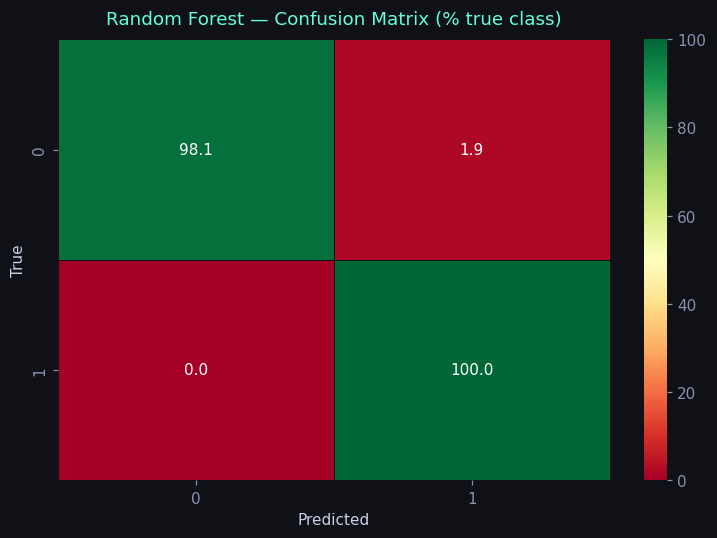

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
unique_labels = np.unique(np.concatenate([y_test, y_pred]))
label_names   = [str(c) for c in le.inverse_transform(unique_labels)]

cm     = confusion_matrix(y_test, y_pred, labels=unique_labels)
cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9) * 100

fig, ax = plt.subplots(figsize=(max(7, len(unique_labels)*0.7),
                                max(5, len(unique_labels)*0.6)))
fig.patch.set_facecolor('#0f1117')
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100,
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='#0f1117', ax=ax)
ax.set_title(f'{best_name} — Confusion Matrix (% true class)',
             color='#64ffda', fontsize=12, pad=10)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()


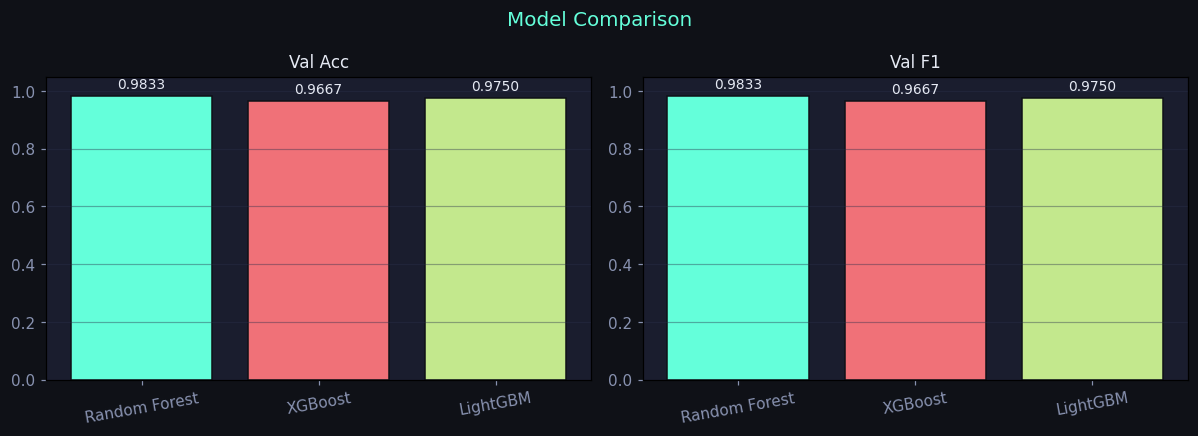

In [ ]:
# ── Model comparison chart ────────────────────────────────────────────────────
comp = pd.DataFrame([{'Model': k, 'Val Acc': v['val_acc'], 'Val F1': v['val_f1']}
                     for k, v in results.items()])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor('#0f1117')
for ax, col in zip(axes, ['Val Acc', 'Val F1']):
    bars = ax.bar(comp['Model'], comp[col], color=PALETTE[:3], edgecolor='#0f1117')
    ax.set_title(col, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    ax.set_xticklabels(comp['Model'], rotation=10)
plt.suptitle('Model Comparison', color='#64ffda', fontsize=13)
plt.tight_layout(); plt.show()


---
## 8. Explainable AI — Feature Importance (SHAP)

In [ ]:
print('Computing SHAP values (may take ~1 min)...')
explainer   = shap.TreeExplainer(best_model)
shap_sample = X_test.iloc[:500] if hasattr(X_test, 'iloc') else X_test[:500]
shap_values = explainer.shap_values(shap_sample)
print('Done!')


Computing SHAP values (may take ~1 min)...
Done!


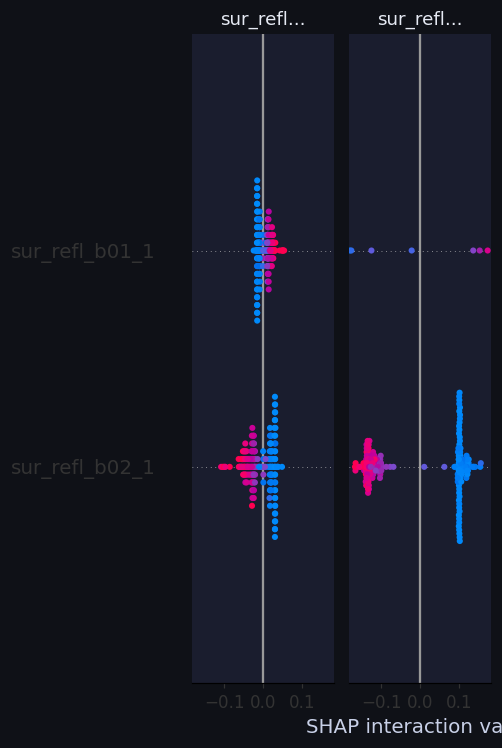

In [ ]:
# Mean absolute SHAP across classes
if isinstance(shap_values, list):
    shap_mean = np.abs(np.array(shap_values)).mean(axis=0)
else:
    shap_mean = shap_values

shap.summary_plot(shap_mean, shap_sample,
                  feature_names=num_features_eng,
                  plot_type='bar', show=True)


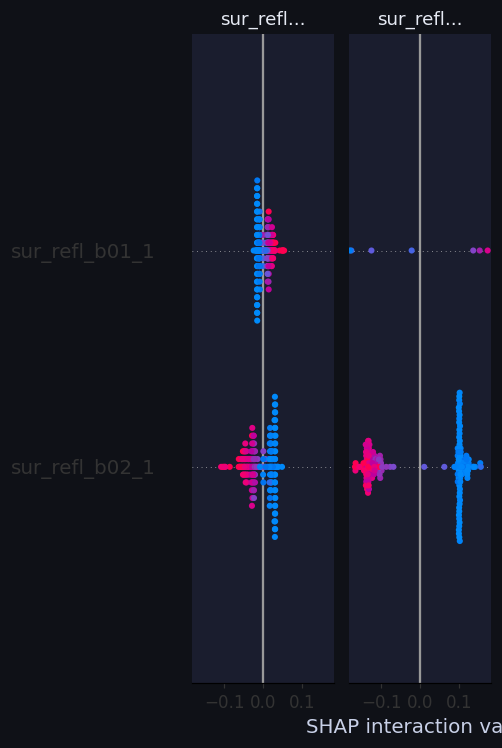

In [ ]:
# Beeswarm for first class
sv_class0 = shap_values[0] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv_class0, shap_sample,
                  feature_names=num_features_eng, show=True)


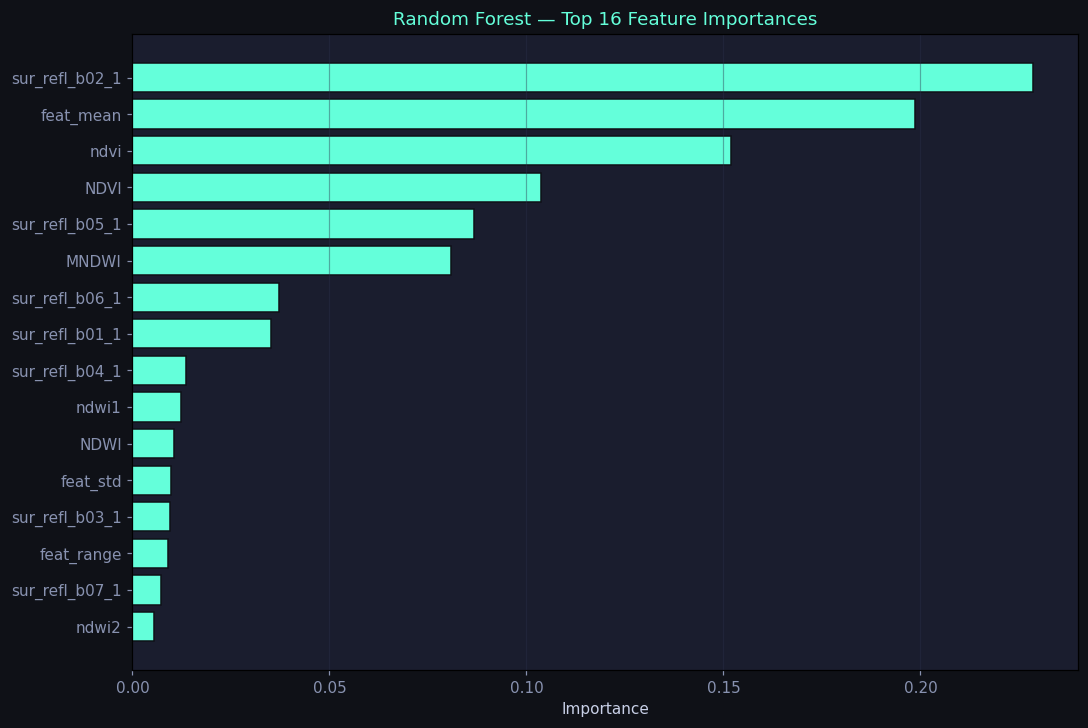

In [ ]:
# Built-in feature importance
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_,
                    index=num_features_eng).sort_values(ascending=False)
    top_n = min(20, len(imp))
    fig, ax = plt.subplots(figsize=(10, top_n*0.42))
    fig.patch.set_facecolor('#0f1117')
    ax.barh(imp.index[:top_n][::-1], imp.values[:top_n][::-1],
            color=PALETTE[0], edgecolor='#0f1117')
    ax.set_title(f'{best_name} — Top {top_n} Feature Importances',
                 color='#64ffda', fontsize=12)
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.4)
    plt.tight_layout(); plt.show()


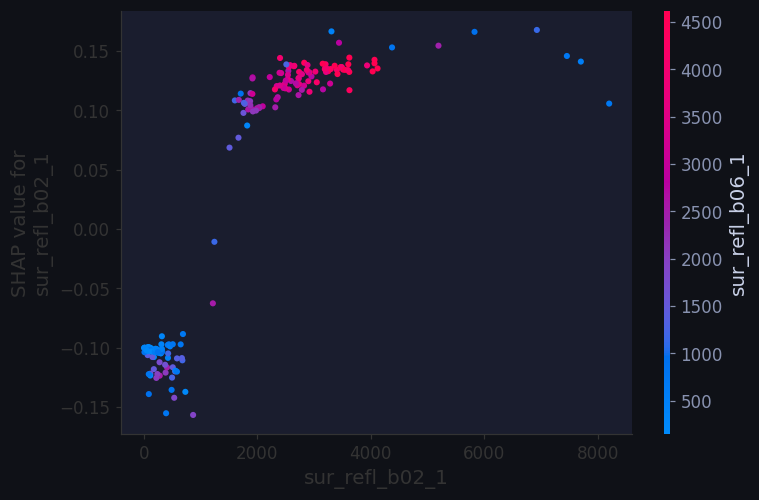

In [ ]:
import numpy as np
# SHAP dependence plot — most important feature
if hasattr(best_model, 'feature_importances_'):
    top_feat = imp.index[0]
else:
    top_feat = num_features_eng[0]
idx = num_features_eng.index(top_feat)

# Ensure sv_class0 is 2D for dependence_plot, extracting for class 0
# shap_values is (num_samples, num_features, num_classes)
# so shap_values[:, :, 0] extracts SHAP values for the first class (class 0)
# The variable sv_class0 from the previous cell is 3D, so we re-slice it here.
sv_class0_for_dep_plot = shap_values[:, :, 0]

shap.dependence_plot(idx, sv_class0_for_dep_plot, shap_sample,
                     feature_names=num_features_eng, show=True)

---
## Summary

| Step | Details |
|------|---------|
| 1 | Libraries installed and imported |
| 2 | Dataset loaded from HuggingFace + target column auto-detected |
| 3 | 5 EDA visualisations |
| 4 | Feature engineering: spectral indices + statistical aggregates |
| 5 | **LabelEncoder fit only on train** — XGBoost-compatible consecutive classes |
| 6 | Random Forest, XGBoost, LightGBM — best selected by F1 + 5-fold CV |
| 7 | Accuracy, F1, confusion matrix, model comparison |
| 8 | SHAP bar, beeswarm, dependence + built-in importance |
